In [89]:
import matplotlib.pyplot as plt
%matplotlib inline

In [90]:
filename="actor7.wav"

In [91]:
import resampy
import IPython.display as ipd
import librosa
import librosa.display
import numpy as np

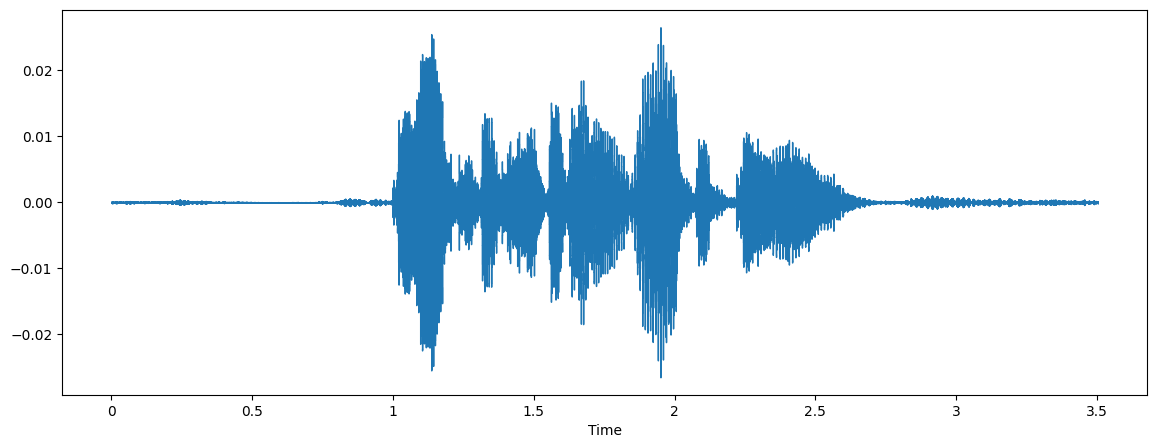

In [92]:
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(filename)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(filename)

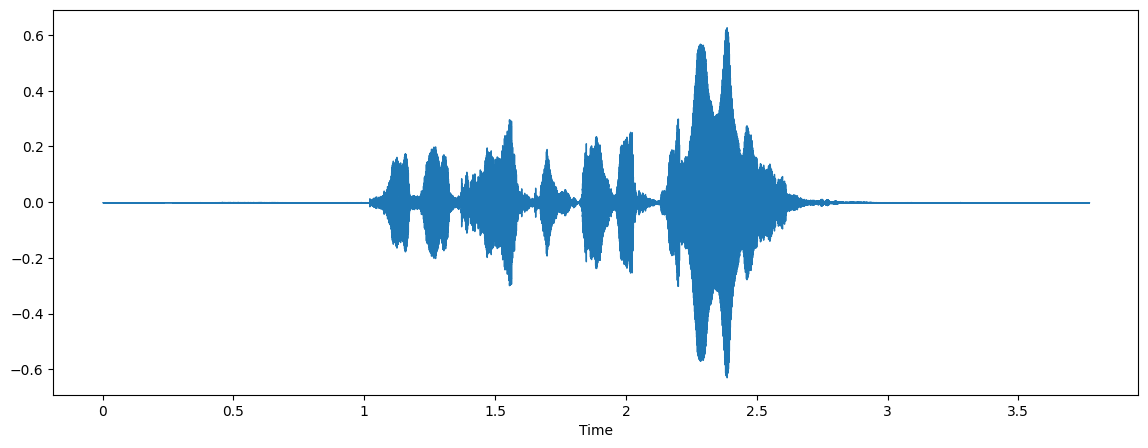

In [93]:
filename='audio2.wav'
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(filename)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(filename)

In [94]:
sample_rate

22050

In [95]:
from scipy.io import wavfile 
wave_sample_rate, wave_audio=wavfile.read(filename)

C:\Users\umesh sonawane\AppData\Local\Temp\ipykernel_18860\3732132886.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  wave_sample_rate, wave_audio=wavfile.read(filename)


In [96]:
wave_sample_rate

48000

In [97]:
wave_audio

array([0, 0, 0, ..., 0, 0, 0], dtype=int16)

In [98]:
data

array([-3.3246260e-14, -2.4372702e-13,  8.8606050e-14, ...,
        1.1333642e-07, -9.5980688e-08,  0.0000000e+00], dtype=float32)

In [99]:
import os
import pandas as pd

def parse_filename(file):
    parts = file[:-4].split("-")  
    return {
        "filename": file,
        "modality": parts[0],
        "vocal_channel": parts[1],
        "emotion": parts[2],
        "intensity": parts[3],
        "statement": parts[4],
        "repetition": parts[5],
        "actor_id": parts[6],
    }


root_path = r"C:/Users/umesh sonawane/OneDrive/Desktop/audio_classification/audio_classification/audioclassificationapp"

data = []

for dirpath, dirnames, filenames in os.walk(root_path):
    for file in filenames:
        if file.endswith(".wav"):
            try:
                metadata = parse_filename(file)
                metadata["filepath"] = os.path.join(dirpath, file)
                data.append(metadata)
            except (IndexError, ValueError):
                
                continue

df = pd.DataFrame(data)
df.to_csv("audio_classification_metadata.csv", index=False)

print(f"Metadata CSV saved with {len(df)} valid entries.")


Metadata CSV saved with 2880 valid entries.


In [100]:
df = pd.read_csv("audio_classification_metadata.csv")
df.head()

,filename,modality,vocal_channel,emotion,intensity,statement,repetition,actor_id,filepath
0,03-01-01-01-01-01-01.wav,3,1,1,1,1,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...
1,03-01-01-01-01-02-01.wav,3,1,1,1,1,2,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...
2,03-01-01-01-02-01-01.wav,3,1,1,1,2,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...
3,03-01-01-01-02-02-01.wav,3,1,1,1,2,2,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...
4,03-01-02-01-01-01-01.wav,3,1,2,1,1,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...


In [101]:
print(df.shape)

(2880, 9)


In [102]:
emotion_map = {
    1: 'neutral',
    2: 'calm',
    3: 'happy',
    4: 'sad',
    5: 'angry',
    6: 'fearful',
    7: 'disgust',
    8: 'surprised'
}

df['emotion_label'] = df['emotion'].map(emotion_map)




In [103]:
df.head(5)

,filename,modality,vocal_channel,emotion,intensity,statement,repetition,actor_id,filepath,emotion_label
0,03-01-01-01-01-01-01.wav,3,1,1,1,1,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,neutral
1,03-01-01-01-01-02-01.wav,3,1,1,1,1,2,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,neutral
2,03-01-01-01-02-01-01.wav,3,1,1,1,2,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,neutral
3,03-01-01-01-02-02-01.wav,3,1,1,1,2,2,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,neutral
4,03-01-02-01-01-01-01.wav,3,1,2,1,1,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,calm


In [104]:
df['emotion_label'].value_counts()

emotion_label
calm         384
happy        384
sad          384
angry        384
disgust      384
fearful      384
surprised    384
neutral      192
Name: count, dtype: int64

In [105]:
audio_file_path='audio2.wav'
librosa_audio_data,librosa_sample_rate=librosa.load(audio_file_path)

In [106]:
print(librosa_audio_data)

[-3.3246260e-14 -2.4372702e-13  8.8606050e-14 ...  1.1333642e-07
 -9.5980688e-08  0.0000000e+00]


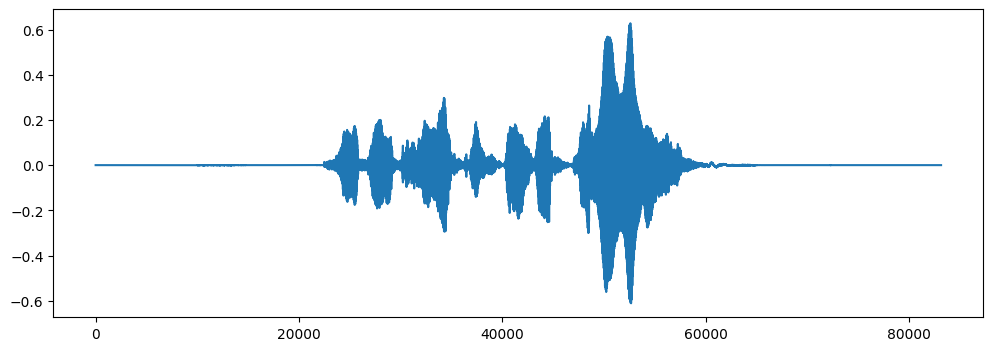

In [107]:
plt.figure(figsize=(12, 4))
plt.plot(librosa_audio_data)

In [108]:
from scipy.io import wavfile 
wave_sample_rate, wave_audio = wavfile.read(audio_file_path) 

C:\Users\umesh sonawane\AppData\Local\Temp\ipykernel_18860\892467306.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  wave_sample_rate, wave_audio = wavfile.read(audio_file_path)


In [109]:
wave_audio

array([0, 0, 0, ..., 0, 0, 0], dtype=int16)

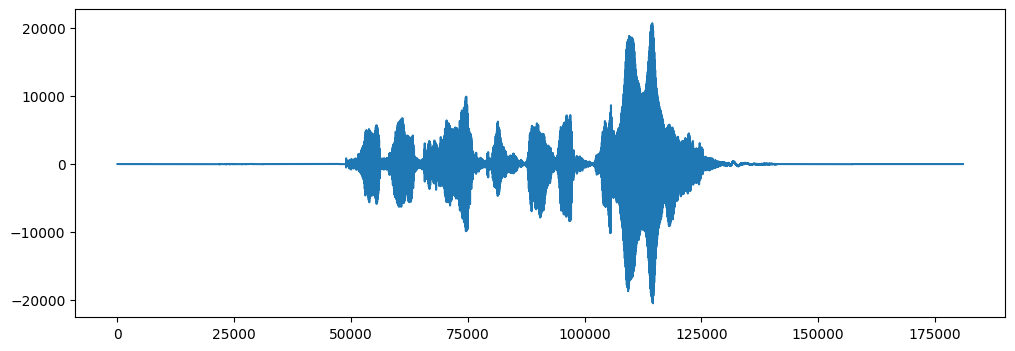

In [110]:
plt.figure(figsize=(12, 4))
plt.plot(wave_audio)

In [111]:
df.to_csv("updated_metadata_with_labels.csv", index=False)


In [112]:
mfccs = librosa.feature.mfcc(y=librosa_audio_data, sr=librosa_sample_rate, n_mfcc=40)
print(mfccs.shape)

(40, 163)


In [113]:
mfccs

array([[-528.35504, -528.35504, -528.35504, ..., -528.35504, -528.35504,
        -528.35504],
       [   0.     ,    0.     ,    0.     , ...,    0.     ,    0.     ,
           0.     ],
       [   0.     ,    0.     ,    0.     , ...,    0.     ,    0.     ,
           0.     ],
       ...,
       [   0.     ,    0.     ,    0.     , ...,    0.     ,    0.     ,
           0.     ],
       [   0.     ,    0.     ,    0.     , ...,    0.     ,    0.     ,
           0.     ],
       [   0.     ,    0.     ,    0.     , ...,    0.     ,    0.     ,
           0.     ]], dtype=float32)

In [114]:
audio_dataset_path='audioclassificationapp/archive'
metadata=pd.read_csv('updated_metadata_with_labels.csv')
metadata.head()

,filename,modality,vocal_channel,emotion,intensity,statement,repetition,actor_id,filepath,emotion_label
0,03-01-01-01-01-01-01.wav,3,1,1,1,1,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,neutral
1,03-01-01-01-01-02-01.wav,3,1,1,1,1,2,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,neutral
2,03-01-01-01-02-01-01.wav,3,1,1,1,2,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,neutral
3,03-01-01-01-02-02-01.wav,3,1,1,1,2,2,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,neutral
4,03-01-02-01-01-01-01.wav,3,1,2,1,1,1,1,C:/Users/umesh sonawane/OneDrive/Desktop/audio...,calm


In [115]:
def features_extractor(file):
    audio, sample_rate = librosa.load(file, res_type='kaiser_fast') 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)
    return mfccs_scaled_features

In [116]:
import sys

# Pre-load resampy manually so that lazy.load won't fail
import resampy
sys.modules["resampy"] = resampy

import librosa  # Now it should not fail at lazy.load("resampy")


In [117]:
import resampy
resampy.__version__

'0.4.2'

In [118]:
import glob
from glob import glob
from tqdm import tqdm

base_audio_dir = r"C:/Users/umesh sonawane/OneDrive\Desktop/audio_classification/audio_classification/audioclassificationapp/archive"

wav_files = glob(os.path.join(base_audio_dir, '**', '*.wav'), recursive=True)
print(f"Total audio files found: {len(wav_files)}")

def extract_features(file_path):
    try:
        audio, sample_rate = librosa.load(file_path, sr=None)  
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfccs_scaled = np.mean(mfccs.T, axis=0)
        return mfccs_scaled
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def get_emotion_id(file_path):
    try:
        file_name = os.path.basename(file_path)
        parts = file_name.split("-")
        if len(parts) >= 3:
            return int(parts[2])
        else:
            return None
    except:
        return None

features = []

for file in tqdm(wav_files):
    emotion_id = get_emotion_id(file)
    if emotion_id is None or emotion_id not in emotion_map:
        continue
    label = emotion_map[emotion_id]
    feature_vector = extract_features(file)
    if feature_vector is not None:
        features.append([feature_vector, label])


features_df = pd.DataFrame(features, columns=['feature', 'emotion_label'])

features_expanded = pd.DataFrame(features_df['feature'].tolist())
features_expanded['emotion_label'] = features_df['emotion_label']


features_expanded.to_csv("extracted_features.csv", index=False)
print("Feature extraction completed and saved to 'extracted_features.csv'")


Total audio files found: 2880


100%|██████████| 2880/2880 [02:27<00:00, 19.46it/s]


Feature extraction completed and saved to 'extracted_features.csv'


In [119]:
features_df.head()

,feature,emotion_label
0,"[-726.2172, 68.54142, 3.2933977, 12.2053, 5.51...",neutral
1,"[-719.1283, 70.20157, 1.168397, 13.122541, 7.8...",neutral
2,"[-714.9957, 69.68935, 3.9245636, 11.92419, 6.4...",neutral
3,"[-710.9753, 67.56488, 5.7822413, 13.230726, 6....",neutral
4,"[-759.92175, 75.78352, 6.0236053, 14.557394, 6...",calm


In [166]:
X=np.array(features_df['feature'].tolist())
y=np.array(features_df['emotion_label'].tolist())

In [167]:
X.shape

(2880, 40)

In [168]:
y

array(['neutral', 'neutral', 'neutral', ..., 'surprised', 'surprised',
       'surprised'], dtype='<U9')

In [123]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [169]:
y

array(['neutral', 'neutral', 'neutral', ..., 'surprised', 'surprised',
       'surprised'], dtype='<U9')

In [170]:
from sklearn.model_selection import train_test_split
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)


X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)


In [171]:
from sklearn.model_selection import train_test_split
X_cnn = np.expand_dims(X, -1)  

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_categorical, test_size=0.2, random_state=42)

In [173]:
X_train

array([[[-7.1421179e+02],
        [ 8.3852577e+01],
        [ 4.0629964e+00],
        ...,
        [-7.0422673e-01],
        [-1.4998376e+00],
        [-4.5744720e-01]],

       [[-6.6491772e+02],
        [ 9.2848007e+01],
        [-3.6773832e+00],
        ...,
        [-2.4022963e+00],
        [-1.4017470e+00],
        [ 5.7405603e-01]],

       [[-6.2132812e+02],
        [ 6.8568832e+01],
        [-2.2176456e+01],
        ...,
        [ 1.7418573e+00],
        [ 5.4536980e-01],
        [ 8.4090537e-01]],

       ...,

       [[-4.5216623e+02],
        [ 3.5141911e+01],
        [-2.3503103e+01],
        ...,
        [ 3.6177728e+00],
        [-9.1660172e-01],
        [ 1.5472891e+00]],

       [[-4.6372495e+02],
        [ 4.5929325e+01],
        [-1.6501160e+01],
        ...,
        [ 2.6824129e+00],
        [ 1.1677670e+00],
        [-1.0886872e+00]],

       [[-6.4703296e+02],
        [ 8.2198990e+01],
        [ 2.7478769e+00],
        ...,
        [ 1.1353463e+00],
        [-9.641

In [172]:
y

array(['neutral', 'neutral', 'neutral', ..., 'surprised', 'surprised',
       'surprised'], dtype='<U9')

In [174]:
X_train.shape

(2304, 40, 1)

In [175]:
X_test.shape

(576, 40, 1)

In [176]:
y_train.shape

(2304, 8)

In [177]:
y_test.shape

(576, 8)

In [184]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization 
from tensorflow.keras.callbacks import ModelCheckpoint

In [181]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [185]:
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(40, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_categorical.shape[1], activation='softmax')
])


 

In [186]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,192 (614.03 KB)

 Trainable params: 157,192 (614.03 KB)

 Non-trainable params: 0 (0.00 B)

In [187]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [188]:
print(X_train.shape)


(2304, 40, 1)


In [189]:
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime
import os

# Save best model
os.makedirs("saved_models", exist_ok=True)
checkpoint = ModelCheckpoint(
    "saved_models/audio_classification_cnn.keras",
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

# Train
start = datetime.now()
history = model.fit(X_train, y_train, batch_size=32, epochs=100,
                    validation_data=(X_test, y_test),
                    callbacks=[checkpoint], verbose=1)
end = datetime.now()

print(f"Training completed in: {end - start}")


Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1435 - loss: 5.7769
Epoch 1: val_accuracy improved from None to 0.16840, saving model to saved_models/audio_classification_cnn.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.1454 - loss: 3.6427 - val_accuracy: 0.1684 - val_loss: 2.0304
Epoch 2/100
70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1867 - loss: 2.0608
Epoch 2: val_accuracy improved from 0.16840 to 0.21875, saving model to saved_models/audio_classification_cnn.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1892 - loss: 2.0431 - val_accuracy: 0.2188 - val_loss: 1.9420
Epoch 3/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2064 - loss: 2.0027
Epoch 3: val_accuracy improved from 0.21875 to 0.22569, saving model to saved_models/audio_classification_cnn.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2092 - loss: 1.9901 - val_accuracy: 0.2257 - val_loss: 1.8970
Epoch 4/100
70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

In [193]:
from tensorflow.keras.models import load_model

model = load_model("saved_models/audio_classification.keras")

In [194]:
test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])

0.7569444179534912


In [195]:
X_test[1]

array([[-6.5830627e+02],
       [ 7.8063484e+01],
       [-7.8696334e-01],
       [ 1.0139038e+01],
       [ 8.3047256e+00],
       [ 1.2286283e+01],
       [-4.8716979e+00],
       [ 5.2415824e-01],
       [-5.5969224e+00],
       [-3.2145643e+00],
       [-9.8750238e+00],
       [-1.7062539e+00],
       [ 3.7575347e+00],
       [-5.9739370e+00],
       [-3.3157292e-01],
       [ 2.9784529e+00],
       [-3.0217645e+00],
       [-2.5681200e+00],
       [ 3.6451254e+00],
       [-2.1180203e+00],
       [-5.3756080e+00],
       [-2.0939779e+00],
       [ 1.6240497e+00],
       [-1.1843982e+00],
       [-3.4878762e+00],
       [-3.2193878e+00],
       [-4.2661497e-01],
       [-1.2460377e+00],
       [-5.8568640e+00],
       [-6.3024521e-01],
       [-4.6622038e-01],
       [-1.6577942e+00],
       [-2.3192806e+00],
       [-1.4580050e+00],
       [-1.3490732e+00],
       [-3.2940543e+00],
       [-7.9161758e-03],
       [-1.3784134e+00],
       [-3.1171269e+00],
       [-7.9918444e-01]],

In [207]:
from tensorflow.keras.utils import to_categorical
y_train_encoded = to_categorical(y_train)


In [208]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [211]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
import joblib

original_labels = np.argmax(y_train, axis=1)

labelencoder = LabelEncoder()
labelencoder.fit(original_labels)

joblib.dump(labelencoder, 'labelencoder.pkl')


['labelencoder.pkl']

In [213]:
labelencoder = joblib.load("labelencoder.pkl")

filename = "testfile.wav"
audio, sample_rate = librosa.load(filename, res_type='kaiser_fast')
mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
mfccs_scaled = np.mean(mfccs.T, axis=0)
mfccs_scaled = mfccs_scaled.reshape(1, -1)

pred = model.predict(mfccs_scaled)
predicted_label = np.argmax(pred, axis=1)
predicted_emotion = labelencoder.inverse_transform(predicted_label)

print("Predicted Emotion:", predicted_emotion[0])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Emotion: 1


In [217]:
import pickle
from tensorflow.keras.models import save_model

with open("saved_models/audio_model.pkl", "wb") as f:
    pickle.dump(model, f)
